## YOLOv8 Plate Detection

Environment

In [ ]:
from google.colab import drive
drive.mount("/content/drive")

Mounted at /content/drive


In [ ]:
%pip install ultralytics

import ultralytics
ultralytics.checks()

Ultralytics 8.3.74 🚀 Python-3.11.11 torch-2.5.1+cu124 CUDA:0 (Tesla T4, 15095MiB)
Setup complete ✅ (2 CPUs, 12.7 GB RAM, 33.0/112.6 GB disk)


Dataset

In [ ]:
!unzip data/plate_dataset.zip -d ./data

Archive:  data/plate_dataset.zip
   creating: ./data/plate_dataset/images/
   creating: ./data/plate_dataset/images/test/
  inflating: ./data/plate_dataset/images/test/108.jpg  
  inflating: ./data/plate_dataset/images/test/130.jpg  
  inflating: ./data/plate_dataset/images/test/145.jpg  
  inflating: ./data/plate_dataset/images/test/151.jpg  
  inflating: ./data/plate_dataset/images/test/165.jpg  
  inflating: ./data/plate_dataset/images/test/169.jpg  
  inflating: ./data/plate_dataset/images/test/180.jpg  
  inflating: ./data/plate_dataset/images/test/201.jpg  
  inflating: ./data/plate_dataset/images/test/203.jpg  
  inflating: ./data/plate_dataset/images/test/205.jpg  
  inflating: ./data/plate_dataset/images/test/206.jpg  
  inflating: ./data/plate_dataset/images/test/240.jpg  
  inflating: ./data/plate_dataset/images/test/241.jpg  
  inflating: ./data/plate_dataset/images/test/243.jpg  
  inflating: ./data/plate_dataset/images/test/247.jpg  
  inflating: ./data/plate_dataset/imag

Train

In [ ]:
!yolo detect train data=data/config.yaml model=yolov8n.pt epochs=100 patience=30 imgsz=640 workers=8 batch=16 device=0 name=yolov8n-plate-detection

Ultralytics 8.3.74 🚀 Python-3.11.11 torch-2.5.1+cu124 CUDA:0 (Tesla T4, 15095MiB)
engine/trainer: task=detect, mode=train, model=yolov8n.pt, data=data/config.yaml, epochs=100, time=None, patience=30, batch=16, imgsz=640, save=True, save_period=-1, cache=False, device=0, workers=8, project=None, name=yolov8n-plate-detection4, exist_ok=False, pretrained=True, optimizer=auto, verbose=True, seed=0, deterministic=True, single_cls=False, rect=False, cos_lr=False, close_mosaic=10, resume=False, amp=True, fraction=1.0, profile=False, freeze=None, multi_scale=False, overlap_mask=True, mask_ratio=4, dropout=0.0, val=True, split=val, save_json=False, save_hybrid=False, conf=None, iou=0.7, max_det=300, half=False, dnn=False, plots=True, source=None, vid_stride=1, stream_buffer=False, visualize=False, augment=False, agnostic_nms=False, classes=None, retina_masks=False, embed=None, show=False, save_frames=False, save_txt=False, save_conf=False, save_crop=False, show_labels=True, show_conf=True, show

Prediction

In [ ]:
import cv2
import imutils
from ultralytics import YOLO
from google.colab.patches import cv2_imshow


0: 416x640 1 licence_plate, 66.8ms
Speed: 4.6ms preprocess, 66.8ms inference, 207.6ms postprocess per image at shape (1, 3, 416, 640)


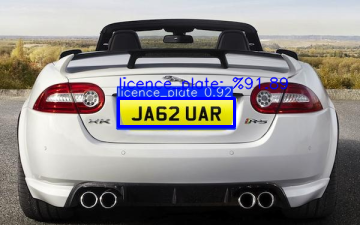

In [ ]:
img_path = "runs/detect/predict2/108.jpg"
model_path = "runs/detect/yolov8n-plate-detection4/weights/best.pt"

font = cv2.FONT_HERSHEY_SIMPLEX

model = YOLO(model_path)
img = cv2.imread(img_path)
img = imutils.resize(img, width=360) # aspect ratio

results = model(img)[0]

threshold = 0.5
for result in results.boxes.data.tolist():
  x1, y1, x2, y2, score, class_id = result
  x1, y1, x2, y2, class_id = int(x1), int(y1), int(x2), int(y2), int(class_id)
  if score > threshold:
    cv2.rectangle(img, (x1,y1), (x2,y2), (255,0,0), 2)

    class_name = results.names[class_id]
    score = score * 100

    text = f"{class_name}: %{score:.2f}"

    cv2.putText(img, text, (x1, y1-10), font, 0.5, (255,0,0), 1, cv2.LINE_AA)

cv2_imshow(img)
